# 🚦 Analyse Exploratoire des Données — Barbados Traffic Analysis Challenge


---

## 🎯 Contexte

Prédire le **niveau de congestion 5 minutes dans le futur** à partir de 4 flux vidéo d'un rond-point à la Barbade.

**Targets :** `congestion_enter_rating` et `congestion_exit_rating` (multi-label, classification ordinale)  
**Métrique :** Macro-F1 (70%) + Accuracy (30%)  
**Contrainte :** Backpropagation interdite — extraction de features + classifieur classique

---

## Colonnes clés

| Colonne | Type | Rôle |
|---------|------|------|
| `videos` | string | Chemin vers la vidéo mp4 |
| `congestion_enter_rating` | ordinal | Label 1 — congestion entrée |
| `congestion_exit_rating` | ordinal | Label 2 — congestion sortie |
| `time_segment_id` | int | Feature temporelle |
| `cycle_phase` | catégoriel | Phase du feu de signalisation |
| `signaling` | catégoriel | Type de signalisation |

## 📦 1. Importation des bibliothèques

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Bibliothèques chargées ✅')

Bibliothèques chargées ✅


## 📥 2. Chargement des données

In [25]:
DATASET_PATH = '/kaggle/input/datasets/kipngetichv/reencoded-barbados-traffic/'
LABEL_COLS   = ['congestion_enter_rating', 'congestion_exit_rating']
CAT_COLS     = ['signaling', 'cycle_phase']
TEMP_COLS    = ['time_segment_id']

train = pd.read_csv(os.path.join(DATASET_PATH, 'Train.csv'))
sub   = pd.read_csv(os.path.join(DATASET_PATH, 'SampleSubmission.csv'))

print(f'Train : {train.shape[0]} lignes x {train.shape[1]} colonnes')
print(f'Colonnes : {train.columns.tolist()}')

Train : 16076 lignes x 14 colonnes
Colonnes : ['responseId', 'view_label', 'ID_enter', 'ID_exit', 'videos', 'video_time', 'datetimestamp_start', 'datetimestamp_end', 'date', 'signaling', 'congestion_enter_rating', 'congestion_exit_rating', 'time_segment_id', 'cycle_phase']


In [26]:
train.head(10)

,responseId,view_label,ID_enter,ID_exit,videos,video_time,datetimestamp_start,datetimestamp_end,date,signaling,congestion_enter_rating,congestion_exit_rating,time_segment_id,cycle_phase
0,zYkHaeOdB7XOnvgP3YW5kQs,Norman Niles #1,time_segment_0_Norman Niles #1_congestion_ente...,time_segment_0_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-00-45.mp4,2025-10-20 06:00:45,2025-10-20 06:00:45,2025-10-20 06:01:44,2025-10-20,none,free flowing,free flowing,0,train
1,NYsHaeCRLq-vnvgPjoXZqA0,Norman Niles #1,time_segment_1_Norman Niles #1_congestion_ente...,time_segment_1_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-01-45.mp4,2025-10-20 06:01:45,2025-10-20 06:01:45,2025-10-20 06:02:44,2025-10-20,none,free flowing,free flowing,1,train
2,A40HaYT8KNm7nvgPq8e12AU,Norman Niles #1,time_segment_2_Norman Niles #1_congestion_ente...,time_segment_2_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-02-45.mp4,2025-10-20 06:02:45,2025-10-20 06:02:45,2025-10-20 06:03:00,2025-10-20,none,free flowing,free flowing,2,train
3,EIsHaanDMK-vnvgPjoXZqA0,Norman Niles #1,time_segment_3_Norman Niles #1_congestion_ente...,time_segment_3_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-03-45.mp4,2025-10-20 06:03:45,2025-10-20 06:03:45,2025-10-20 06:04:44,2025-10-20,none,free flowing,free flowing,3,train
4,RYsHafSeMaqpmecP5vCV0AQ,Norman Niles #1,time_segment_4_Norman Niles #1_congestion_ente...,time_segment_4_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-04-45.mp4,2025-10-20 06:04:45,2025-10-20 06:04:45,2025-10-20 06:04:59,2025-10-20,none,free flowing,free flowing,4,train
5,SIsHaebOK7mfnvgPoaTSqQ0,Norman Niles #1,time_segment_5_Norman Niles #1_congestion_ente...,time_segment_5_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-05-45.mp4,2025-10-20 06:05:45,2025-10-20 06:05:45,2025-10-20 06:06:44,2025-10-20,none,free flowing,free flowing,5,train
6,EI0HadH5KqHXnvgP76fxyQI,Norman Niles #1,time_segment_6_Norman Niles #1_congestion_ente...,time_segment_6_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-06-45.mp4,2025-10-20 06:06:45,2025-10-20 06:06:45,2025-10-20 06:07:44,2025-10-20,low,free flowing,free flowing,6,train
7,A40HaYaBG8jtnvgP8NiHuAw,Norman Niles #1,time_segment_7_Norman Niles #1_congestion_ente...,time_segment_7_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-07-45.mp4,2025-10-20 06:07:45,2025-10-20 06:07:45,2025-10-20 06:08:44,2025-10-20,none,free flowing,free flowing,7,train
8,04kHacmOLrXOnvgP3YW5kQs,Norman Niles #1,time_segment_8_Norman Niles #1_congestion_ente...,time_segment_8_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-08-45.mp4,2025-10-20 06:08:45,2025-10-20 06:08:45,2025-10-20 06:09:44,2025-10-20,none,free flowing,free flowing,8,train
9,EI0HaeWIIb-envgP6uGTmAE,Norman Niles #1,time_segment_9_Norman Niles #1_congestion_ente...,time_segment_9_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-09-45.mp4,2025-10-20 06:09:45,2025-10-20 06:09:45,2025-10-20 06:10:44,2025-10-20,none,free flowing,free flowing,9,train


## 🔎 3. Types de données et valeurs manquantes

In [27]:
print('=== Types de données ===')
print(train.dtypes)
print('\n=== Valeurs manquantes ===')
missing = train.isnull().sum()
pct = (missing / len(train) * 100).round(2)
df_m = pd.DataFrame({'Manquants': missing, '%': pct})
display_m = df_m[df_m['Manquants'] > 0]
print(display_m if len(display_m) > 0 else 'Aucune valeur manquante ✅')

=== Types de données ===
responseId                 object
view_label                 object
ID_enter                   object
ID_exit                    object
videos                     object
video_time                 object
datetimestamp_start        object
datetimestamp_end          object
date                       object
signaling                  object
congestion_enter_rating    object
congestion_exit_rating     object
time_segment_id             int64
cycle_phase                object
dtype: object

=== Valeurs manquantes ===
Aucune valeur manquante ✅


## ⚙️ 4. Pré-encodage pour l'analyse

In [29]:
# Encoder labels + catégorielles pour les visualisations numériques
train_enc = train.copy()
label_encoders = {}

for col in LABEL_COLS + CAT_COLS:
    if col in train_enc.columns and train_enc[col].dtype == object:
        le = LabelEncoder()
        train_enc[col + '_enc'] = le.fit_transform(train_enc[col].fillna('unknown').astype(str))
        label_encoders[col] = le
        print(f'{col} -> {dict(zip(le.classes_, range(len(le.classes_))))}')
    elif col in train_enc.columns:
        train_enc[col + '_enc'] = train_enc[col]

print('\nEncodage terminé ✅')

congestion_enter_rating -> {'free flowing': 0, 'heavy delay': 1, 'light delay': 2, 'moderate delay': 3}
congestion_exit_rating -> {'free flowing': 0, 'heavy delay': 1, 'light delay': 2, 'moderate delay': 3}
signaling -> {'high': 0, 'low': 1, 'medium': 2, 'none': 3}
cycle_phase -> {'train': 0}

Encodage terminé ✅


## ⚖️ 5. Distribution des labels (multi-label)

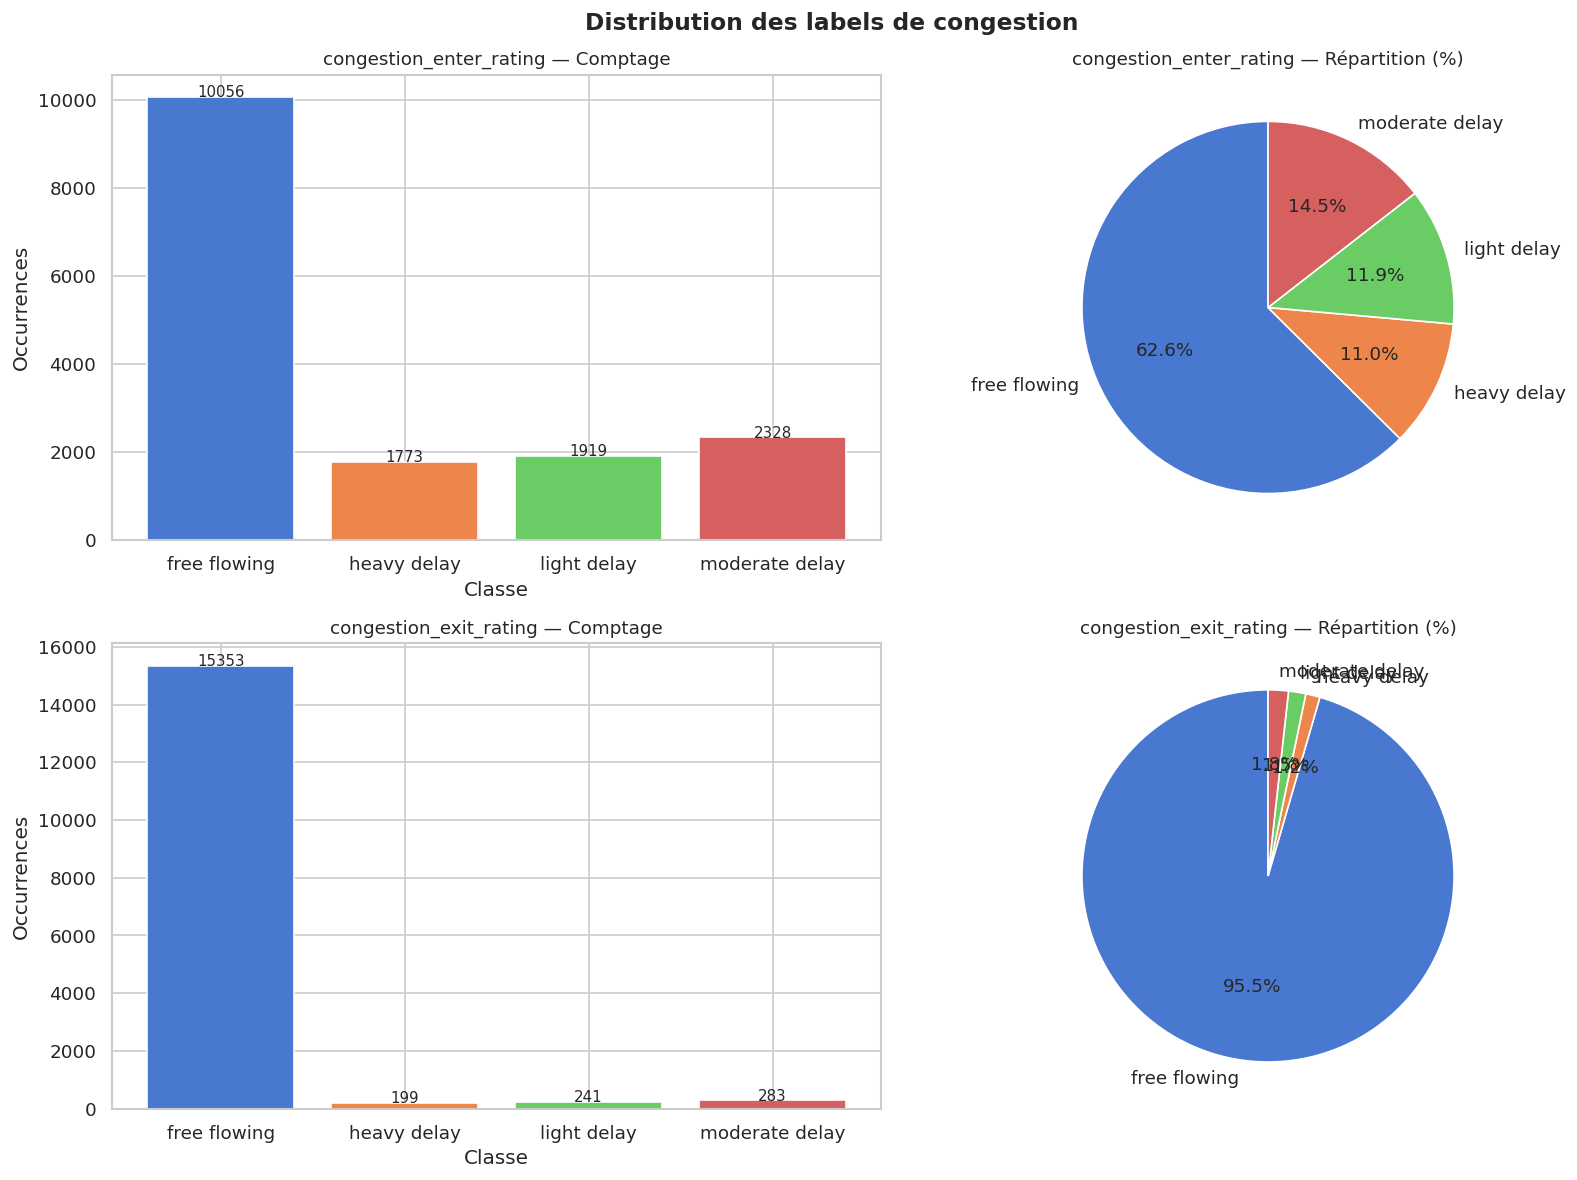


📊 Déséquilibre des classes :
  congestion_enter_rating: ratio max/min = 5.67x — ⚠️ Déséquilibre
  congestion_exit_rating: ratio max/min = 77.15x — ⚠️ Déséquilibre


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution des labels de congestion', fontsize=14, fontweight='bold')
palette = sns.color_palette('muted', 10)

for i, col in enumerate(LABEL_COLS):
    if col not in train.columns:
        continue
    counts = train[col].value_counts().sort_index()

    bars = axes[i][0].bar(counts.index.astype(str), counts.values,
                          color=palette[:len(counts)], edgecolor='white')
    axes[i][0].set_title(f'{col} — Comptage', fontsize=11)
    axes[i][0].set_xlabel('Classe')
    axes[i][0].set_ylabel('Occurrences')
    for bar, val in zip(bars, counts.values):
        axes[i][0].text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 1, str(val), ha='center', fontsize=9)

    axes[i][1].pie(counts.values, labels=counts.index.astype(str),
                   autopct='%1.1f%%', colors=palette[:len(counts)], startangle=90)
    axes[i][1].set_title(f'{col} — Répartition (%)', fontsize=11)

plt.tight_layout()
plt.show()

print('\n📊 Déséquilibre des classes :')
for col in LABEL_COLS:
    if col in train.columns:
        c = train[col].value_counts().sort_index()
        ratio = c.max() / c.min()
        flag = '⚠️ Déséquilibre' if ratio > 2 else '✅ Équilibré'
        print(f'  {col}: ratio max/min = {ratio:.2f}x — {flag}')

## 🔗 6. Corrélation enter ↔ exit


💡 Corrélation Pearson enter ↔ exit : 0.137


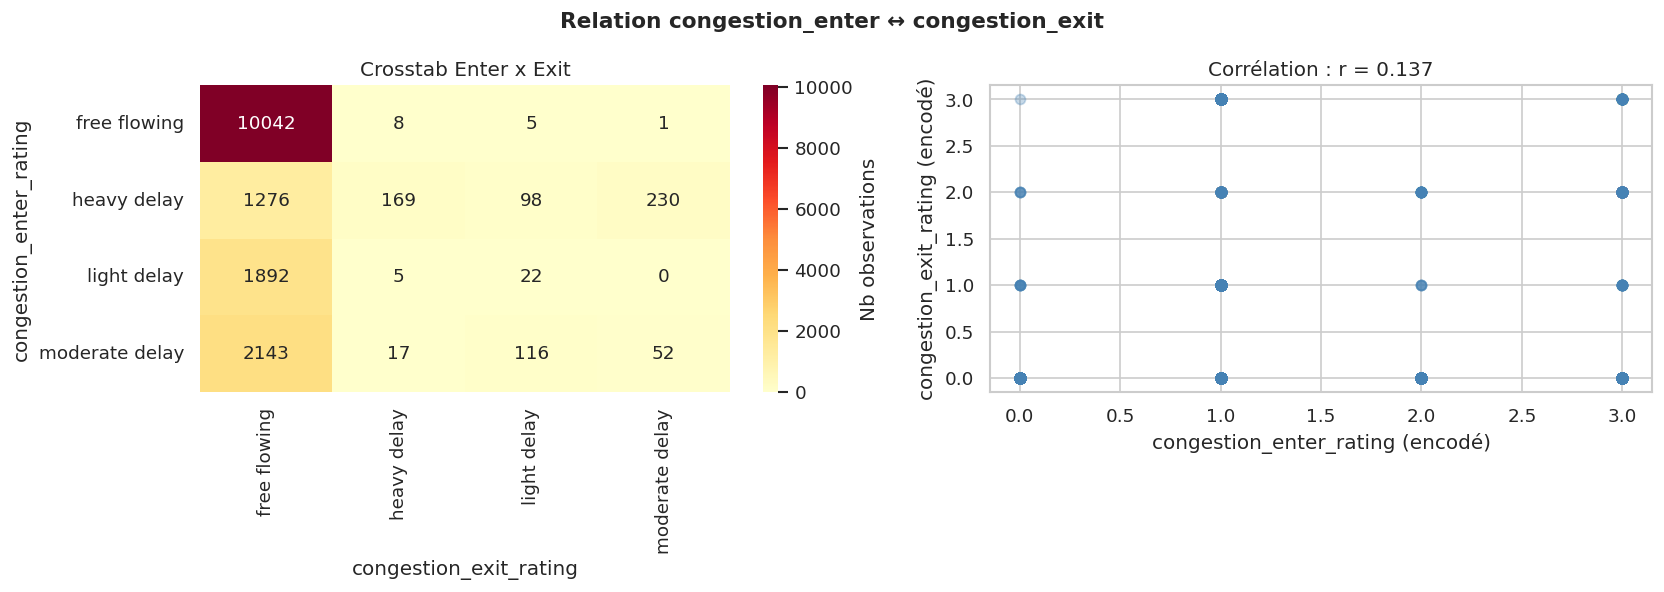

In [31]:
enc_enter = LABEL_COLS[0] + '_enc'
enc_exit  = LABEL_COLS[1] + '_enc'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Relation congestion_enter ↔ congestion_exit', fontsize=13, fontweight='bold')

if LABEL_COLS[0] in train.columns and LABEL_COLS[1] in train.columns:
    ct = pd.crosstab(train[LABEL_COLS[0]], train[LABEL_COLS[1]])
    sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
                cbar_kws={'label': 'Nb observations'})
    axes[0].set_title('Crosstab Enter x Exit')

    if enc_enter in train_enc.columns and enc_exit in train_enc.columns:
        corr = train_enc[[enc_enter, enc_exit]].corr().iloc[0, 1]
        axes[1].scatter(train_enc[enc_enter], train_enc[enc_exit], alpha=0.3, color='steelblue')
        axes[1].set_title(f'Corrélation : r = {corr:.3f}')
        axes[1].set_xlabel('congestion_enter_rating (encodé)')
        axes[1].set_ylabel('congestion_exit_rating (encodé)')
        print(f'\n💡 Corrélation Pearson enter ↔ exit : {corr:.3f}')

plt.tight_layout()
plt.show()

## 📹 7. Variables catégorielles — `signaling` et `cycle_phase`

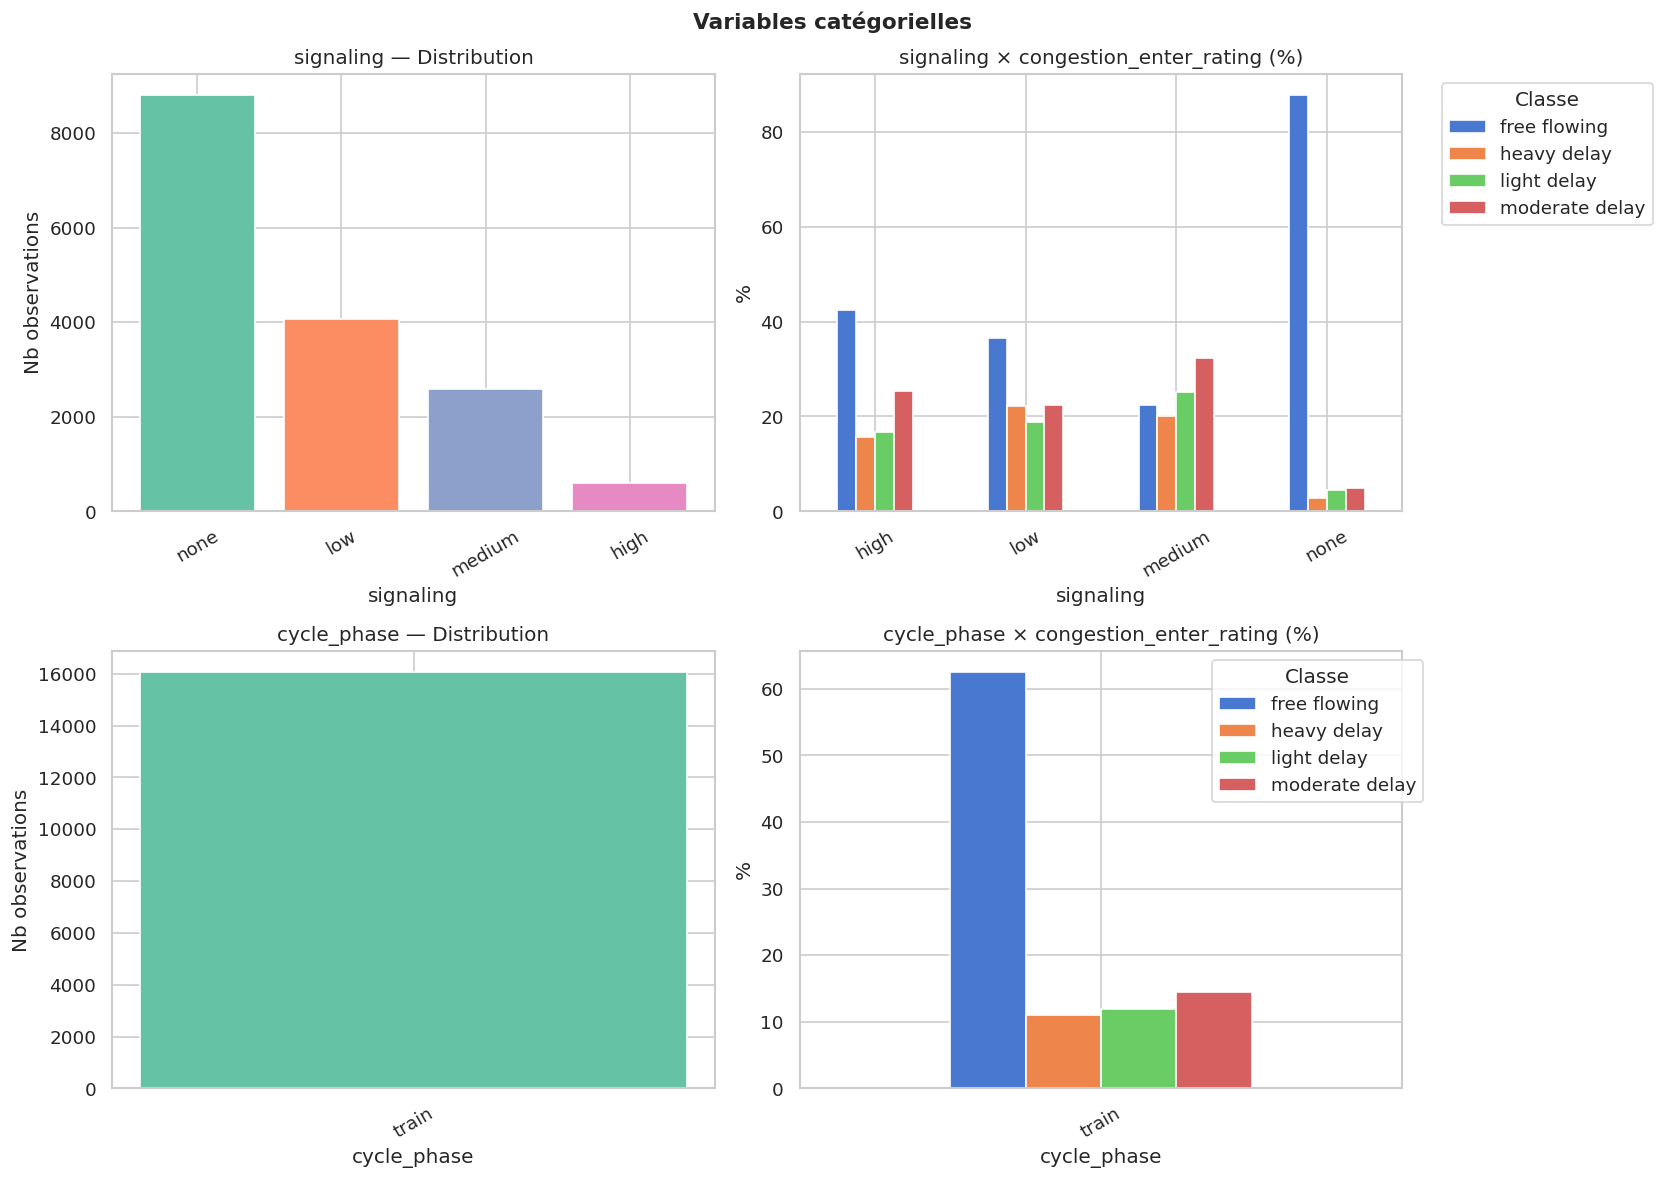

In [41]:
available_cat = [c for c in CAT_COLS if c in train.columns]

if available_cat:
    fig, axes = plt.subplots(len(available_cat), 2, figsize=(14, 5 * len(available_cat)))
    if len(available_cat) == 1:
        axes = [axes]
    fig.suptitle('Variables catégorielles', fontsize=13, fontweight='bold')

    for i, col in enumerate(available_cat):
        counts = train[col].value_counts()
        axes[i][0].bar(counts.index.astype(str), counts.values,
                       color=sns.color_palette('Set2', len(counts)))
        axes[i][0].set_title(f'{col} — Distribution')
        axes[i][0].set_xlabel(col)
        axes[i][0].set_ylabel('Nb observations')
        axes[i][0].tick_params(axis='x', rotation=30)

        if LABEL_COLS[0] in train.columns:
            ct = pd.crosstab(train[col], train[LABEL_COLS[0]], normalize='index') * 100
            colors = sns.color_palette('muted', len(ct.columns))
            ct.plot(kind='bar', ax=axes[i][1], color=colors, edgecolor='white')
            axes[i][1].set_title(f'{col} × congestion_enter_rating (%)')
            axes[i][1].set_xlabel(col)
            axes[i][1].set_ylabel('%')
            axes[i][1].tick_params(axis='x', rotation=30)
            axes[i][1].legend(title='Classe', bbox_to_anchor=(1.05, 1))

    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Aucune colonne catégorielle disponible')

## 🕐 8. Feature temporelle — `time_segment_id`

time_segment_id — min: 0, max: 4986, nunique: 4019


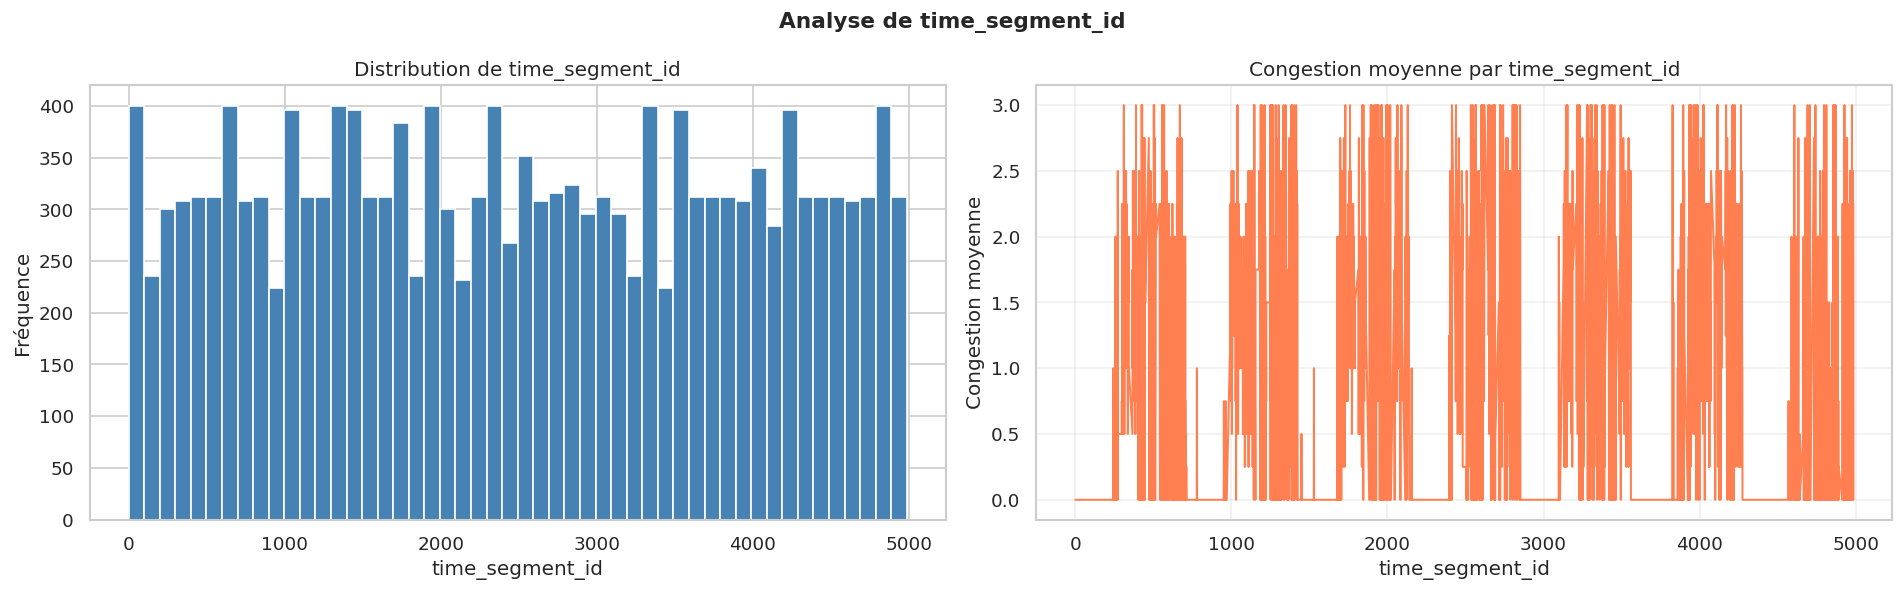

In [33]:
if 'time_segment_id' in train.columns:
    print(f"time_segment_id — min: {train['time_segment_id'].min()}, "
          f"max: {train['time_segment_id'].max()}, nunique: {train['time_segment_id'].nunique()}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Analyse de time_segment_id', fontsize=13, fontweight='bold')

    axes[0].hist(train['time_segment_id'], bins=50, color='steelblue', edgecolor='white')
    axes[0].set_title('Distribution de time_segment_id')
    axes[0].set_xlabel('time_segment_id')
    axes[0].set_ylabel('Fréquence')

    enc_col = enc_enter if enc_enter in train_enc.columns else LABEL_COLS[0]
    if enc_col in train_enc.columns:
        ts_mean = train_enc.groupby('time_segment_id')[enc_col].mean()
        axes[1].plot(ts_mean.index, ts_mean.values, color='coral', linewidth=1.2)
        axes[1].set_title('Congestion moyenne par time_segment_id')
        axes[1].set_xlabel('time_segment_id')
        axes[1].set_ylabel('Congestion moyenne')
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Colonne 'time_segment_id' non présente")

## 🌡️ 9. Heatmap — Congestion × cycle_phase × signaling

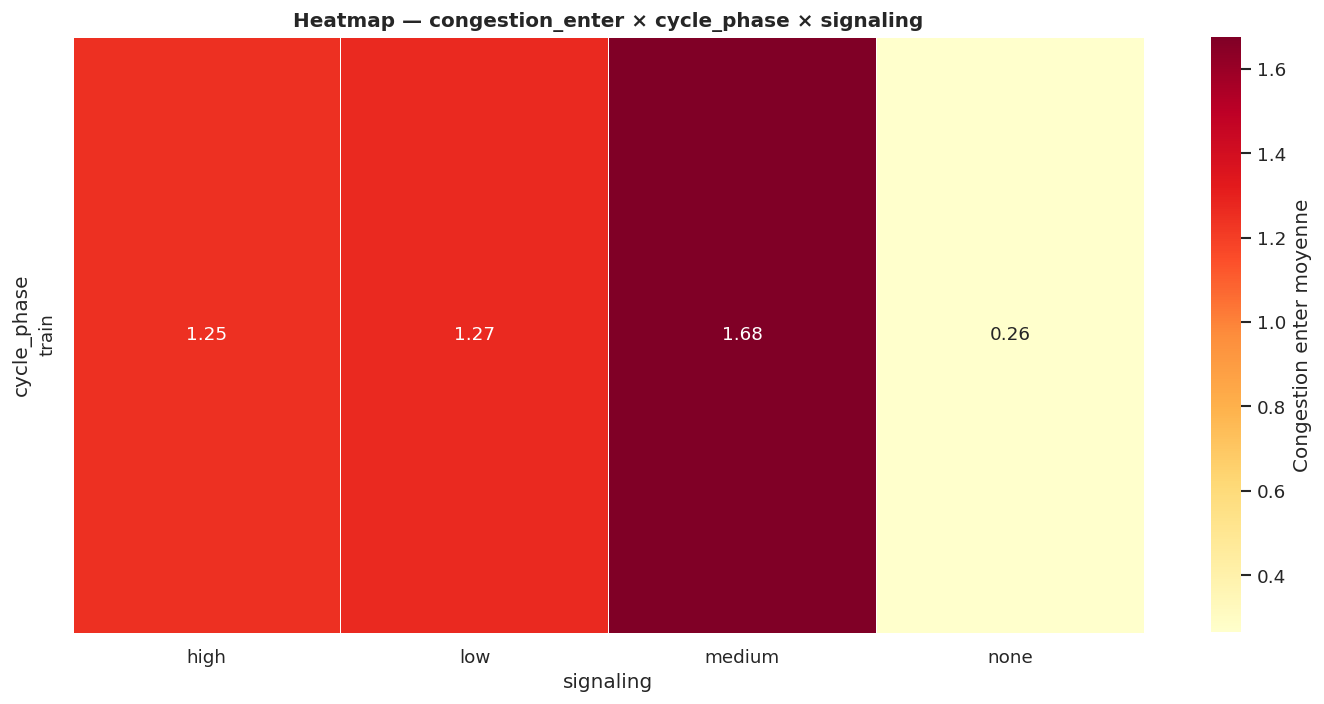


💡 Zones rouges = combinaisons les plus congestionnées.


In [34]:
if 'cycle_phase' in train.columns and 'signaling' in train.columns and enc_enter in train_enc.columns:
    pivot = train_enc.pivot_table(values=enc_enter,
                                  index='cycle_phase',
                                  columns='signaling',
                                  aggfunc='mean')

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.2f',
                linewidths=0.3, ax=ax,
                cbar_kws={'label': 'Congestion enter moyenne'})
    ax.set_title('Heatmap — congestion_enter × cycle_phase × signaling',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('\n💡 Zones rouges = combinaisons les plus congestionnées.')
else:
    print('⚠️ Colonnes cycle_phase ou signaling manquantes')

## 📈 10. Série temporelle enter vs exit

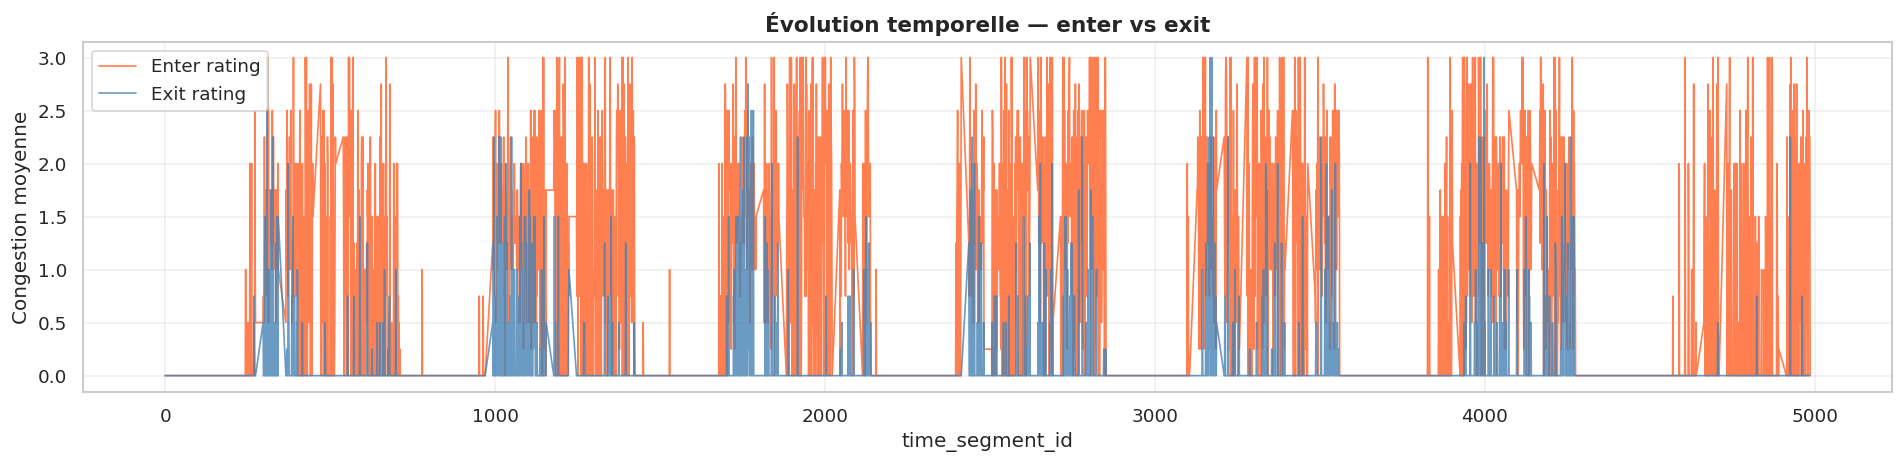

In [35]:
if 'time_segment_id' in train.columns and enc_enter in train_enc.columns and enc_exit in train_enc.columns:
    ts_enter = train_enc.groupby('time_segment_id')[enc_enter].mean()
    ts_exit  = train_enc.groupby('time_segment_id')[enc_exit].mean()

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(ts_enter.index, ts_enter.values, label='Enter rating', color='coral', linewidth=1)
    ax.plot(ts_exit.index,  ts_exit.values,  label='Exit rating',  color='steelblue', linewidth=1, alpha=0.8)
    ax.set_title('Évolution temporelle — enter vs exit', fontsize=13, fontweight='bold')
    ax.set_xlabel('time_segment_id')
    ax.set_ylabel('Congestion moyenne')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Données temporelles non disponibles')

## 🔗 11. Matrice de corrélation globale

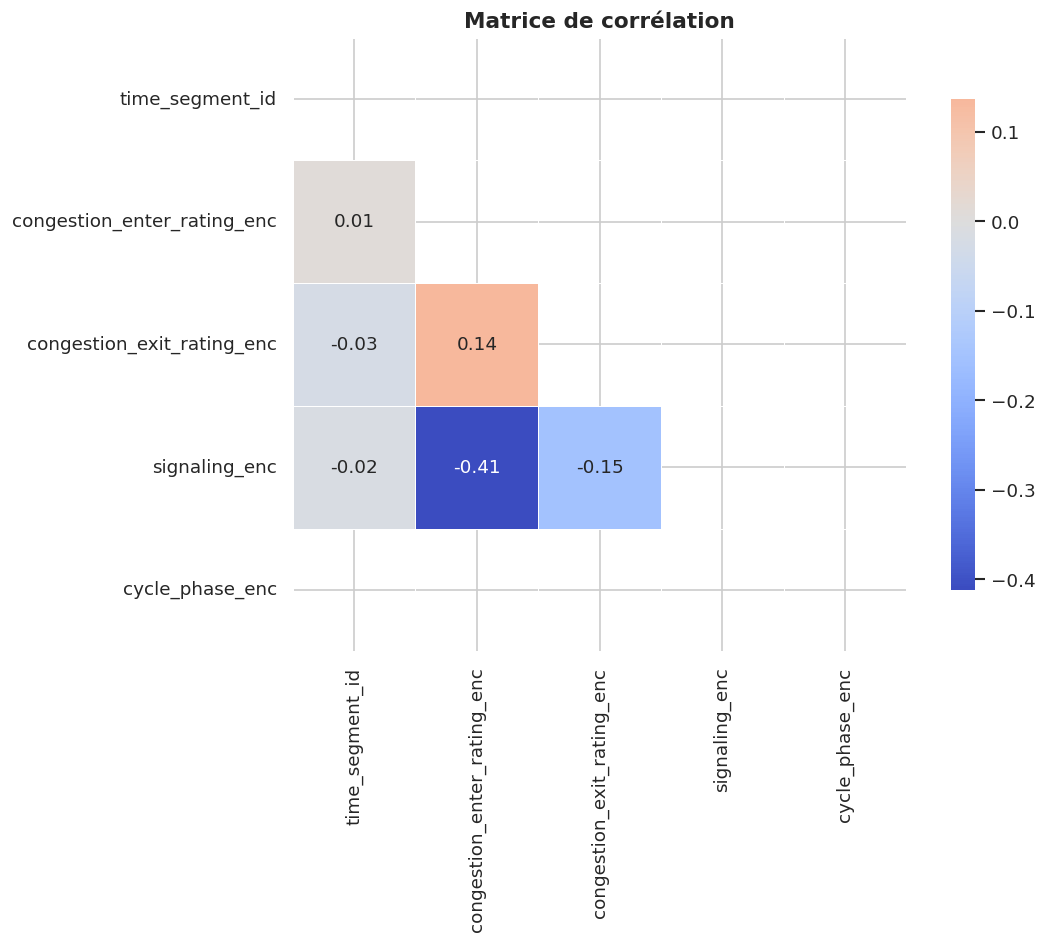

In [36]:
enc_available = [c + '_enc' for c in LABEL_COLS + CAT_COLS if c + '_enc' in train_enc.columns]
num_cols = [c for c in train_enc.select_dtypes(include=[np.number]).columns
            if c in enc_available or c in TEMP_COLS]

if len(num_cols) >= 2:
    corr = train_enc[num_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5,
                cbar_kws={'shrink': .8}, ax=ax)
    ax.set_title('Matrice de corrélation', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Pas assez de colonnes numériques')

## 📊 12. Statistiques par classe

In [37]:
for col in LABEL_COLS:
    if col not in train.columns:
        continue
    print(f'\n=== {col} ===')
    rows = []
    for cls in sorted(train[col].unique()):
        subset = train[train[col] == cls]
        row = {'Classe': cls, 'Nb': len(subset), '%': f'{len(subset)/len(train)*100:.1f}%'}
        if 'time_segment_id' in train.columns:
            row['time_seg_mean'] = f"{subset['time_segment_id'].mean():.1f}"
        rows.append(row)
    print(pd.DataFrame(rows).to_string(index=False))


=== congestion_enter_rating ===
        Classe    Nb     % time_seg_mean
  free flowing 10056 62.6%        2500.0
   heavy delay  1773 11.0%        2334.3
   light delay  1919 11.9%        2528.4
moderate delay  2328 14.5%        2550.6

=== congestion_exit_rating ===
        Classe    Nb     % time_seg_mean
  free flowing 15353 95.5%        2503.1
   heavy delay   199  1.2%        2062.6
   light delay   241  1.5%        2357.6
moderate delay   283  1.8%        2332.7


## ✅ 14. Résumé et recommandations

| Observation | Impact | Recommandation |
|-------------|--------|----------------|
| **Multi-label** (`enter` + `exit`) | 2 sorties | Têtes de classification séparées |
| **Labels ordinaux** | Erreurs lointaines plus graves | Quadratic Weighted Kappa (QWK) |
| **Déséquilibre de classes** | Biais majoritaire | `class_weight='balanced'` + Macro-F1 |
| **`cycle_phase` + `signaling`** | Variables explicatives fortes | Embeddings catégoriels |
| **`time_segment_id`** | Dépendances temporelles | Features de lag + normalisation |
| **4 flux vidéo** | Perspectives complémentaires | EfficientNet → LSTM bidirectionnel |
| **Backprop interdite** | Pas de fine-tuning end-to-end | Backbone gelé + AdamW sur projection |

---

### 🔄 Pipeline

```
EDA (ce notebook)
    ↓
005-feature-extraction-torch.ipynb  (EfficientNet-B2 → embeddings parquet)
    ↓
006-transfert-learning.ipynb  (LSTM bidirectionnel + multi-label + callbacks)
    ↓
Prédiction congestion T+5min → soumission Zindi
```